In [88]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients"
)

print("Dataset downloaded to:", path)
print("Files:")

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))


Dataset downloaded to: C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1
Files:
C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv


In [89]:
import pandas as pd

diabetes_data = pd.read_csv(r"C:\Users\nicol\.cache\kagglehub\datasets\mobeenfatimah\diabetes-risk-prediction-dataset-50k-patients\versions\1\diabetes_risk_prediction_dataset.csv")
#print(diabetes_data)
diabetes_df = pd.DataFrame(diabetes_data)
ini_N_rows = diabetes_df.shape[0]
print(diabetes_df.head())
print("---------")
print(diabetes_df.info())
print("---------")
print(diabetes_df.shape)

   Patient_ID   Age Gender        Country  Height_cm  Weight_kg   BMI  \
0           1  32.0   Male         Mexico      182.1       65.8  19.8   
1           2  42.0  Other   Saudi Arabia      148.5      101.2  45.9   
2           3  89.0  Other      Argentina      158.1        NaN  37.9   
3           4  87.0  Other  United States      190.9       95.9  26.3   
4           5  27.0  Other      Australia      156.9      101.9  41.4   

   Waist_Circumference_cm  Blood_Glucose  HbA1c  ...  Fatty_Liver  PCOS  \
0                    71.2           88.4   10.4  ...          Yes    No   
1                   121.8          247.3   11.3  ...          Yes   Yes   
2                   131.8          141.9    6.3  ...          Yes    No   
3                    99.1           90.1    7.4  ...           No    No   
4                    77.1           93.8   12.0  ...          Yes   Yes   

   Medication_Adherence   Work_Type  Residence_Type  Daily_Water_Intake_L  \
0                  Good     Retir

In [90]:
print(f"Missing values: {diabetes_df.isnull().sum()}")

Missing values: Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Fami

In [91]:
#Make missing values uniform in format
diabetes_df = diabetes_df.replace("",pd.NA)

#exclude columsn where more than 1/10th of all rows are empty, 
#for possible future changes in the data
column_cutoff = diabetes_df.shape[0]/10
print(column_cutoff)
diabetes_df = diabetes_df.dropna(axis = 1, thresh=column_cutoff)
print(diabetes_df.shape)

5000.0
(50000, 41)


In [92]:

#Drop rows with age missing. Too basic of an indicator to miss and makes up only a small % of datapoints. 
#Missing age can be nothing else than data integrity issues
#No significant bias expected in why some datapoints have no registered age.
diabetes_df= diabetes_df. dropna(axis=0, subset=['Age'])
print(diabetes_df.shape)
#Same reasoning for glucose level, with the comment that absence of this information
#might be an indicator for subpar healthcare or on the other hand, no noticable health issues to warrant 
#medical research. Significant bias not probable, but possible
#the presence of the insulin levels and fasting blood sugar will lessen any such impact
diabetes_df= diabetes_df. dropna(axis=0, subset=['Blood_Glucose'])
print(diabetes_df.shape)

current_nrows = diabetes_df.shape[0]
filteredrows = round(current_nrows/ini_N_rows *100)
print(f"Datapoints left: {filteredrows}%")

(49503, 41)
(48557, 41)
Datapoints left: 97%


In [93]:
print(diabetes_df['Diabetes_Risk'].value_counts())
#Data seems to be skewed towards people who already 
#had reason to be under the care of medical personnel

Diabetes_Risk
High        35562
Moderate    12540
Low           455
Name: count, dtype: int64


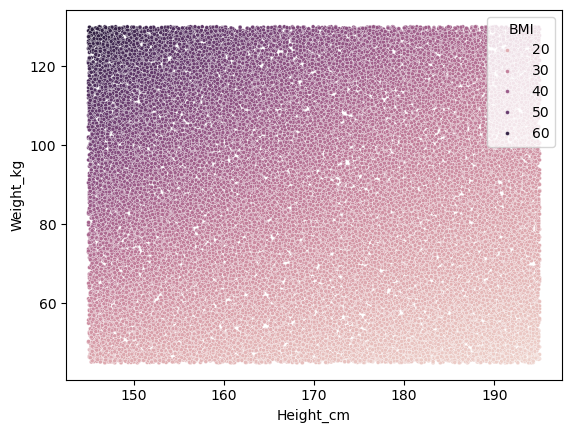

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#plot correlation height,weight, bmi
sns.scatterplot(diabetes_df, x = 'Height_cm', y= 'Weight_kg', hue='BMI', s=3)
plt.show()
#Data integrity; Calcuation of BMI validated
#No apparent clusters of height/weight combinations in overall data

#Possibility to explore, using bmi as stand-in for weight and height. 
#Investigate if height has no inherent influence on diabetes risk
#Or if absolute weight has more impact than BMI

In [94]:
#Feature selection

from sklearn.model_selection import train_test_split 
target = diabetes_df['Diabetes_Risk']
features = diabetes_df.drop(columns=['Diabetes_Risk'])
print(f"Number_of_features: {features.shape[1]}")
print(features.columns)


Number_of_features: 40
Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed'],
      dtype='object')
